In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
import urllib.request

In [2]:
def load_gray_from_url(url):
    data = urllib.request.urlopen(url).read()
    arr = np.frombuffer(data, dtype=np.uint8)
    img = cv2.imdecode(arr, cv2.IMREAD_GRAYSCALE)
    return img

In [3]:
def threshold_binary(img, thresh, maxval=255):
    img = img.astype(np.float64)
    return np.where(img > thresh, maxval, 0).astype(np.uint8)

In [4]:
def threshold_binary_inv(img, thresh, maxval=255):
    img = img.astype(np.float64)
    return np.where(img > thresh, 0, maxval).astype(np.uint8)

In [5]:
def threshold_tozero(img, thresh):
    img = img.astype(np.float64)
    return np.where(img > thresh, img, 0).astype(np.uint8)

In [6]:
def threshold_tozero_inv(img, thresh):
    img = img.astype(np.float64)
    return np.where(img > thresh, 0, img).astype(np.uint8)

In [7]:
def threshold_trunc(img, thresh):
    img = img.astype(np.float64)
    return np.where(img > thresh, thresh, img).astype(np.uint8)

In [8]:
def gaussian_kernel(size, sigma=None):
    if size % 2 == 0 or size < 3:
        raise ValueError("block_size должен быть нечётным и >= 3")
    if sigma is None:
        sigma = 0.3 * ((size - 1) * 0.5 - 1) + 0.8
    ax = np.arange(-(size // 2), size // 2 + 1, dtype=np.float64)
    xx, yy = np.meshgrid(ax, ax)
    kernel = np.exp(-(xx**2 + yy**2) / (2 * sigma**2))
    kernel /= kernel.sum()
    return kernel

In [9]:
def convolve2d_reflect(img, kernel):
    img = img.astype(np.float64)
    kh, kw = kernel.shape
    ph, pw = kh // 2, kw // 2
    padded = np.pad(img, ((ph, ph), (pw, pw)), mode="reflect")
    h, w = img.shape
    out = np.zeros((h, w), dtype=np.float64)
    for i in range(h):
        for j in range(w):
            region = padded[i:i + kh, j:j + kw]
            out[i, j] = np.sum(region * kernel)
    return out

In [10]:
def adaptive_threshold_gaussian(img, maxval=255, block_size=11, C=2, inverse=False):
    if img.ndim != 2:
        raise ValueError("Нужно grayscale изображение")
    kernel = gaussian_kernel(block_size)
    local_thresh = convolve2d_reflect(img, kernel) - C
    if inverse:
        result = np.where(img > local_thresh, 0, maxval)
    else:
        result = np.where(img > local_thresh, maxval, 0)
    return result.astype(np.uint8)

In [11]:
img = load_gray_from_url("https://raw.githubusercontent.com/opencv/opencv/master/samples/data/sudoku.png")

binary = threshold_binary(img, 127, 255)
binary_inv = threshold_binary_inv(img, 127, 255)
tozero = threshold_tozero(img, 127)
tozero_inv = threshold_tozero_inv(img, 127)
trunc = threshold_trunc(img, 127)
adaptive_gauss = adaptive_threshold_gaussian(img, maxval=255, block_size=11, C=2, inverse=False)

cv_binary = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)[1]
cv_binary_inv = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)[1]
cv_tozero = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO)[1]
cv_tozero_inv = cv2.threshold(img, 127, 255, cv2.THRESH_TOZERO_INV)[1]
cv_trunc = cv2.threshold(img, 127, 255, cv2.THRESH_TRUNC)[1]
cv_adaptive_gauss = cv2.adaptiveThreshold(
    img,
    255,
    cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
    cv2.THRESH_BINARY,
    11,
    2
)

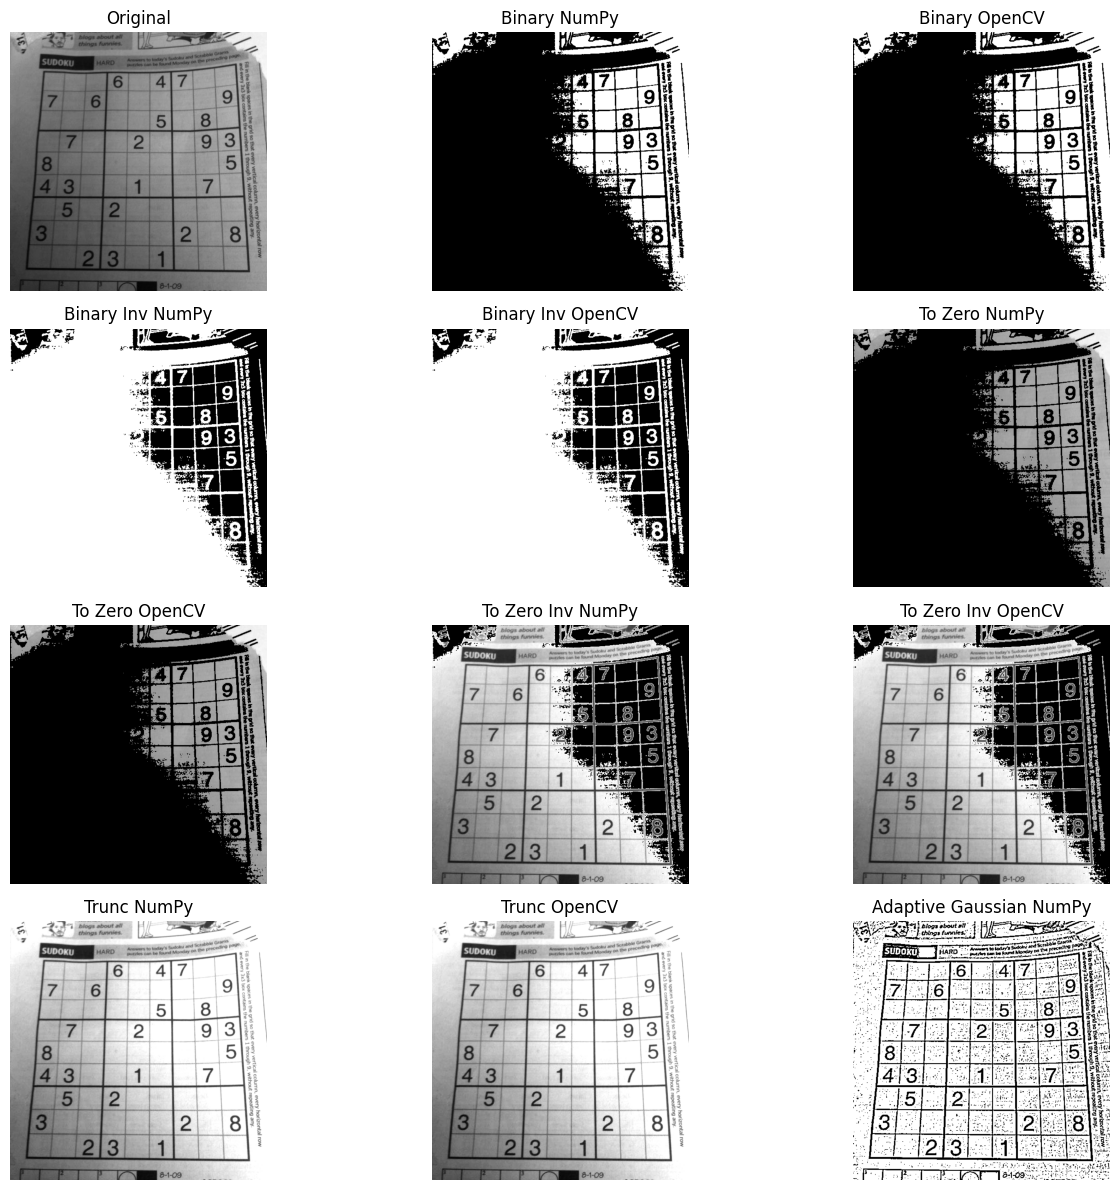

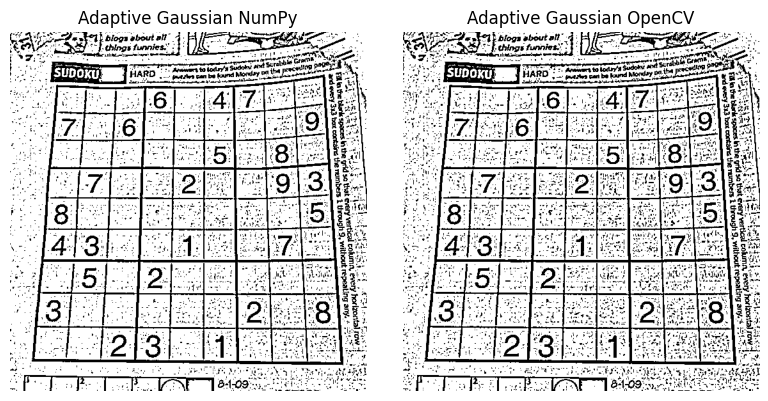

In [12]:
plt.figure(figsize=(14, 12))

plt.subplot(4, 3, 1)
plt.imshow(img, cmap="gray")
plt.title("Original")
plt.axis("off")

plt.subplot(4, 3, 2)
plt.imshow(binary, cmap="gray")
plt.title("Binary NumPy")
plt.axis("off")

plt.subplot(4, 3, 3)
plt.imshow(cv_binary, cmap="gray")
plt.title("Binary OpenCV")
plt.axis("off")

plt.subplot(4, 3, 4)
plt.imshow(binary_inv, cmap="gray")
plt.title("Binary Inv NumPy")
plt.axis("off")

plt.subplot(4, 3, 5)
plt.imshow(cv_binary_inv, cmap="gray")
plt.title("Binary Inv OpenCV")
plt.axis("off")

plt.subplot(4, 3, 6)
plt.imshow(tozero, cmap="gray")
plt.title("To Zero NumPy")
plt.axis("off")

plt.subplot(4, 3, 7)
plt.imshow(cv_tozero, cmap="gray")
plt.title("To Zero OpenCV")
plt.axis("off")

plt.subplot(4, 3, 8)
plt.imshow(tozero_inv, cmap="gray")
plt.title("To Zero Inv NumPy")
plt.axis("off")

plt.subplot(4, 3, 9)
plt.imshow(cv_tozero_inv, cmap="gray")
plt.title("To Zero Inv OpenCV")
plt.axis("off")

plt.subplot(4, 3, 10)
plt.imshow(trunc, cmap="gray")
plt.title("Trunc NumPy")
plt.axis("off")

plt.subplot(4, 3, 11)
plt.imshow(cv_trunc, cmap="gray")
plt.title("Trunc OpenCV")
plt.axis("off")

plt.subplot(4, 3, 12)
plt.imshow(adaptive_gauss, cmap="gray")
plt.title("Adaptive Gaussian NumPy")
plt.axis("off")

plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4))

plt.subplot(1, 2, 1)
plt.imshow(adaptive_gauss, cmap="gray")
plt.title("Adaptive Gaussian NumPy")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(cv_adaptive_gauss, cmap="gray")
plt.title("Adaptive Gaussian OpenCV")
plt.axis("off")

plt.tight_layout()
plt.show()